# Style Transfer Notebook README

This notebook implements neural style transfer, a technique that creates a new image by combining the visual structure of a content image with the texture and artistic patterns of a style image. Instead of training a new network, the notebook keeps a pretrained VGG19 convolutional network fixed and uses it only as a feature extractor.

The core optimization variable is the generated input image itself. The algorithm starts from an initial image, then repeatedly updates its pixel values so that two objectives are satisfied at the same time: a low style loss and a low content loss. The model weights are frozen, and only the generated image is changed during optimization.

The style loss is computed by passing both the style image and the generated image through selected VGG19 layers, converting their feature maps into Gram matrices, and matching those Gram matrices. This captures texture, color relationships, and repeating visual patterns without enforcing exact spatial alignment. The content loss is computed by matching feature maps between the generated image and the content image, which encourages the final result to preserve the main objects and overall layout of the content image.

With these two losses combined, the notebook uses LBFGS to iteratively refine the generated image until it better reflects the style target while still retaining the content target. The notebook is organized so the early sections define the image helpers and loss functions, the middle section builds the VGG19-based feature extraction pipeline, and the final sections run complete style-transfer experiments and visualize the results.


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import models, transforms

import matplotlib.pyplot as plt

from PIL import Image


In [25]:
device = torch.device("mps")

cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)
image_size = 256
loader = transforms.Compose(
    [transforms.Resize((image_size, image_size)), transforms.ToTensor()]
)
unloader = transforms.ToPILImage()


## 1. image_utils


### Section README: Image Utilities

This section defines the low-level helper functions used everywhere else in the notebook. `load_image` reads an image from disk, converts it to RGB, applies the preprocessing transform, and moves the tensor to the selected device. `unload_image` performs the reverse conversion so generated tensors can be visualized with `matplotlib`.

It also defines `get_vgg_gram_matrix`, which converts convolutional feature maps into Gram matrices. Those matrices capture channel-wise texture correlations and are the core representation used for the style objective later in the notebook.


In [26]:
# Image to Tensor
def load_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0)
    return image.to(device)

# Tensor to Image
def unload_image(tensor, title=None):
    image = tensor.cpu().clone().squeeze(0)
    unloader = transforms.ToPILImage()
    image = unloader(image)
    return image

# Get gram matrix of tensor (feature maps)
def get_vgg_gram_matrix(input):
    B, C, H, W = input.shape
    F = input.view(B, C, H * W)
    G = torch.bmm(F, F.transpose(1, 2)) / (C * H * W)
    return G  # [B, C, C]
 

## 2. losses

### Section README: Loss Functions

This section wraps the two optimization targets as PyTorch modules. `StyleLoss` compares Gram matrices between the generated image and the style target, while `ContentLoss` compares feature activations between the generated image and the content target.

Both modules store the computed loss internally and return the input unchanged during `forward`. That design lets them be inserted into a sequential model so the optimization loop can accumulate style and content penalties while still passing activations through the network.


In [27]:
class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        
        self.loss = 0
        self.target = target_feature.detach()
        

    def forward(self, input):
        out = get_vgg_gram_matrix(input)
        self.loss = F.mse_loss(out, self.target)
        return input # Store loss in class and pass the input to next layer

In [28]:
class ContentLoss(nn.Module):
    def __init__(self, feature_map):
        super(ContentLoss, self).__init__()
        
        self.loss = 0
        self.target = feature_map.detach()

    def forward(self, input):
        self.loss = F.mse_loss(input, self.target)
        return input # Store loss in class and pass the input to next layer

## 3. Model

### Section README: Model Construction

This section builds the feature-extraction and optimization pipeline around VGG19. `Normalization` adapts input images to the statistics expected by the pretrained network, `StyleFeaturesExtractor` collects Gram matrices from selected layers, and `ContentFeaturesExtractor` reuses the same truncated model to capture the content representation.

The helper functions here also prepare the optimization problem itself. `get_input_optimizer` creates the LBFGS optimizer over the generated image, and `get_new_model_and_losses` rebuilds a sequential model that inserts the loss modules at the chosen layers so training can optimize the image directly.


In [29]:
# Normalization Layer
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        pass
        #begin_solution
        self.mean = mean.clone().detach().view(-1, 1, 1)  # reshape to [C, 1, 1]
        self.std = std.clone().detach().view(-1, 1, 1)    # reshape to [C, 1, 1]
        #end_solution


    def forward(self, img):
        return (img - self.mean) / self.std

In [30]:
# Get gram matrix of each Relu layer, and return a partial model of vgg19
class StyleFeaturesExtractor:
    def __init__(
        self,
        cnn,
        style_img,
        normalization_mean,
        normalization_std,
        style_layer_idxs=None,
        content_layer_idxs=None
    ):
        self.cnn = cnn
        self.style_img = style_img
        self.normalization_mean = normalization_mean
        self.normalization_std = normalization_std

        self.style_layer_idxs = style_layer_idxs or [1, 6, 11, 20]
        self.content_layer_idxs = content_layer_idxs or [22]

        self.model = None
        self.style_features = {}

        self.build_model_and_extract_features()

    def build_model_and_extract_features(self):
        """
        Build one shared truncated VGG model deep enough for both
        style and content extraction, then store Gram matrices for
        the selected style layers.
        """

        normalization = Normalization(
            self.normalization_mean,
            self.normalization_std
        ).to(device)

        max_required_idx = max(max(self.style_layer_idxs), max(self.content_layer_idxs))

        model = nn.Sequential()
        model.add_module("-1", normalization)

        style_features = {}
        x = self.style_img

        for idx, layer in enumerate(self.cnn.children()):
            if isinstance(layer, nn.ReLU):
                layer = nn.ReLU(inplace=False)

            model.add_module(str(idx), layer)
            x = layer(x)

            if idx in self.style_layer_idxs:
                style_features[idx] = get_vgg_gram_matrix(x).detach()

            if idx >= max_required_idx:
                break

        self.model = model
        self.style_features = style_features

In [31]:
# Get gram matrix of each Relu layer, and return a partial model of vgg19
class ContentFeaturesExtractor:
    def __init__(self, model, content_img, content_layer_idxs=None):
        self.model = model
        self.content_img = content_img
        self.content_layer_idxs = content_layer_idxs or [22]

        self.feature_maps = {}

        self.extract_feature()

    def extract_feature(self):
        """
        Reuse the shared model built by StyleFeatureExtractor and
        extract content feature maps from the selected content layers.
        """

        model = self.model
        feature_maps = {}
        x = self.content_img

        for name, layer in model.named_children():
            x = layer(x)

            if name == "-1":
                continue

            idx = int(name)

            if idx in self.content_layer_idxs:
                feature_maps[idx] = x.detach()

        self.feature_maps = feature_maps
    
    def get_fm(self):
        return self.feature_maps

In [32]:
def get_input_optimizer(input_img):
    optimizer = optim.LBFGS([input_img.requires_grad_()])
    return optimizer

In [33]:
def get_new_model_and_losses(style_features_extractor, content_features_extractor):
    """
    Rebuild the optimization model from the shared extracted model,
    inserting StyleLoss modules at the selected style layers and
    a ContentLoss module at the last selected content layer.
    """

    model = style_features_extractor.model
    new_model = nn.Sequential()

    style_losses = []
    content_loss_module = None

    style_idxs = set(style_features_extractor.style_features.keys())
    content_idxs = list(content_features_extractor.feature_maps.keys())

    if len(content_idxs) == 0:
        raise ValueError("No content feature maps were extracted.")

    last_content_idx = max(content_idxs)

    for name, layer in model.named_children():
        if isinstance(layer, nn.ReLU):
            layer = nn.ReLU(inplace=False)

        new_model.add_module(name, layer)

        if name == "-1":
            continue

        idx = int(name)

        if idx in style_idxs:
            target_gram = style_features_extractor.style_features[idx]
            style_loss = StyleLoss(target_gram)
            new_model.add_module(f"style_loss_{idx}", style_loss)
            style_losses.append(style_loss)

        if idx == last_content_idx:
            target_feature = content_features_extractor.feature_maps[idx]
            content_loss = ContentLoss(target_feature)
            new_model.add_module(f"content_loss_{idx}", content_loss)
            content_loss_module = content_loss

    return new_model, style_losses, content_loss_module

## 4. Run Style Transfer

### Section README: Optimization Loop

This section contains the actual style-transfer execution logic. `run_style_transfer` performs the core iterative optimization, balancing style loss against content loss to update the generated image. The companion function `run_style_transfer_inter` extends that process by optionally saving and displaying intermediate snapshots during optimization.

Together, these functions turn the extracted style targets and content targets into a final stylized image. This is the section where the notebook moves from model definition to image synthesis.


In [34]:
def run_style_transfer(
    style_features_extractor,
    content_features_extractor,
    style_weight,
    content_weight,
    num_steps=2000,):
    """
    Runs the texture transfer optimization process by applying style transfer
    based on the extracted gram matrices. This function updates the input image to
    match the style of the texture image. 

    Parameters:
    -----------
    style_features_extractor : StyleFeaturesExtractor
        An instance of the StyleFeaturesExtractor class that contains the model
        and extracted style features.
        
    content_features_extractor: ContentFeaturesExtractor
        An instance of the ContentFeaturesExtractor class that contains extracted 
        feature maps.

    num_steps : int, optional
        The number of optimization steps to run. Default is 2000.     
        
    style_weight : float between [0,1]
        Determines how much style is the output image going to learn.

    Returns:
    --------
    generated_img : torch.Tensor
        The generated image tensor that has been updated to match the style of the reference image.
    """

    model, style_losses, content_loss_module = get_new_model_and_losses(style_features_extractor=style_features_extractor,
                                                   content_features_extractor=content_features_extractor)
    content_img = content_features_extractor.content_img
        
    ## Make input image a parameter to optimize
    generated_img = content_img.clone().to(device)
    # generated_img = torch.randn(content_img.data.size(), device=device)
    with torch.no_grad():
        generated_img.clamp_(0, 1)
        
    ## Handle optimizer and closure
    optimizer = get_input_optimizer(generated_img)
    
    
    ## Prepare inital loss values for normalise (content is not normalised because initial content loss will be very close to 0)
    model(generated_img)
    initial_style_loss = sum(sl.loss for sl in style_losses).item()
    eps = 1e-8
    

    ## LBFGS closure loop
    run = [0]
    while run[0] <= num_steps:
        
        ## Each step for optimizer 
        def closure():
            with torch.no_grad():
                generated_img.clamp_(0, 1)
            optimizer.zero_grad()
            model(generated_img)                          
            style_loss = sum(sl.loss for sl in style_losses) / len(style_losses)
            normalized_style_loss = style_loss / (initial_style_loss + eps)
            content_loss = content_loss_module.loss
            total = style_weight  * normalized_style_loss + content_weight * content_loss
            total.backward()
            
            run[0] += 1
            if run[0] % 100 == 0:
                print(f"Iteration {run[0]}/{num_steps} | Style Loss: {style_loss.item():.7f} | Normalised Style Loss: {normalized_style_loss.item():.7f}|Content Loss: {content_loss.item():.7f}" )
            
            return total
        
        optimizer.step(closure)
        
        with torch.no_grad():
            generated_img.clamp_(0, 1)

    return generated_img


In [35]:
import matplotlib.pyplot as plt

def run_style_transfer_inter(
    style_features_extractor,
    content_features_extractor,
    style_weight,
    content_weight,
    num_steps=2000,
    show_every=100,
    display_intermediate=True,
    save_intermediate=True,
):
    """
    Runs the style transfer optimization process and optionally
    saves/displays intermediate outputs every `show_every` iterations.

    Returns
    -------
    generated_img : torch.Tensor
        Final stylized image tensor.
    snapshots : list[tuple[int, PIL.Image.Image]]
        List of (iteration, PIL image) intermediate outputs.
    """

    model, style_losses, content_loss_module = get_new_model_and_losses(
        style_features_extractor=style_features_extractor,
        content_features_extractor=content_features_extractor
    )

    content_img = content_features_extractor.content_img

    # Initialize from content image
    generated_img = content_img.clone().to(device) + 0.1 * torch.randn_like(content_img).to(device)

    with torch.no_grad():
        generated_img.clamp_(0, 1)

    optimizer = get_input_optimizer(generated_img)

    # Initial style loss for normalization
    model(generated_img)
    initial_style_loss = sum(sl.loss for sl in style_losses).item()
    eps = 1e-8

    run = [0]
    snapshots = []

    while run[0] < num_steps:

        def closure():
            with torch.no_grad():
                generated_img.clamp_(0, 1)

            optimizer.zero_grad()
            model(generated_img)

            style_loss = sum(sl.loss for sl in style_losses) / len(style_losses)
            normalized_style_loss = style_loss / (initial_style_loss + eps)
            content_loss = content_loss_module.loss

            total = style_weight * normalized_style_loss + content_weight * content_loss
            total.backward()

            run[0] += 1

            if run[0] % show_every == 0 or run[0] == 1 or run[0] == num_steps:
                print(
                    f"Iteration {run[0]}/{num_steps} | "
                    f"Style Loss: {style_loss.item():.7f} | "
                    f"Normalised Style Loss: {normalized_style_loss.item():.7f} | "
                    f"Content Loss: {content_loss.item():.7f}"
                )

                if save_intermediate:
                    img_pil = unload_image(generated_img)
                    snapshots.append((run[0], img_pil.copy()))

                if display_intermediate:
                    img_pil = unload_image(generated_img)
                    plt.figure(figsize=(5, 5))
                    plt.imshow(img_pil)
                    plt.title(f"Iteration {run[0]}")
                    plt.axis("off")
                    plt.show()

            return total

        optimizer.step(closure)

        with torch.no_grad():
            generated_img.clamp_(0, 1)

    return generated_img, snapshots

In [36]:
cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()
for p in cnn.parameters():
    p.requires_grad_(False)
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)
image_size = 256
loader = transforms.Compose(
    [transforms.Resize((image_size, image_size)), transforms.ToTensor()]
)
unloader = transforms.ToPILImage()

## 5. Test Run

### Section README: Experiments And Examples

This section applies the earlier pipeline to real images. It downloads example assets, defines their file paths, loads and previews them, and then runs several style-transfer experiments with different image pairs and hyperparameter settings.

The cells here act as an experimentation area for comparing visual results. They show how changing style weight, content weight, iteration count, or the chosen source images affects the final output and any saved intermediate snapshots.


In [51]:
! wget "https://canada1.discourse-cdn.com/flex035/uploads/mapeditor/original/1X/fe1b62b9657ac8727925b7dc71c7d46a5d2a6a71.png" -O data/tiles.jpg
! wget "https://img.freepik.com/free-vector/black-white-spiral-background_1048-16005.jpg?semt=ais_hybrid&w=740&q=80" -O data/spiral.jpg

--2026-03-23 17:03:15--  https://canada1.discourse-cdn.com/flex035/uploads/mapeditor/original/1X/fe1b62b9657ac8727925b7dc71c7d46a5d2a6a71.png
Resolving canada1.discourse-cdn.com (canada1.discourse-cdn.com)... 18.245.162.28, 18.245.162.120, 18.245.162.42, ...
Connecting to canada1.discourse-cdn.com (canada1.discourse-cdn.com)|18.245.162.28|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 122701 (120K) [image/png]
Saving to: ‘data/tiles.jpg’

data/tiles.jpg      100%[===================>] 119.83K  --.-KB/s    in 0.008s  

2026-03-23 17:03:15 (14.2 MB/s) - ‘data/tiles.jpg’ saved [122701/122701]

--2026-03-23 17:03:15--  https://img.freepik.com/free-vector/black-white-spiral-background_1048-16005.jpg?semt=ais_hybrid&w=740&q=80
Resolving img.freepik.com (img.freepik.com)... 23.200.147.191, 23.200.147.188
Connecting to img.freepik.com (img.freepik.com)|23.200.147.191|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72536 (71K) [image/jpeg]
Sa

In [56]:
mn_img_path = "data/mona_lisa.webp"
abstract_img_path = "data/abstract.webp"
tiles_img_path = "data/tiles.jpg"
spiral_img_path = "data/spiral.jpg"


In [57]:
mn_img = load_image(mn_img_path, loader)
tiles_img = load_image(tiles_img_path, loader)
spiral_img = load_image(spiral_img_path, loader)
abstract_img = load_image(abstract_img_path, loader)

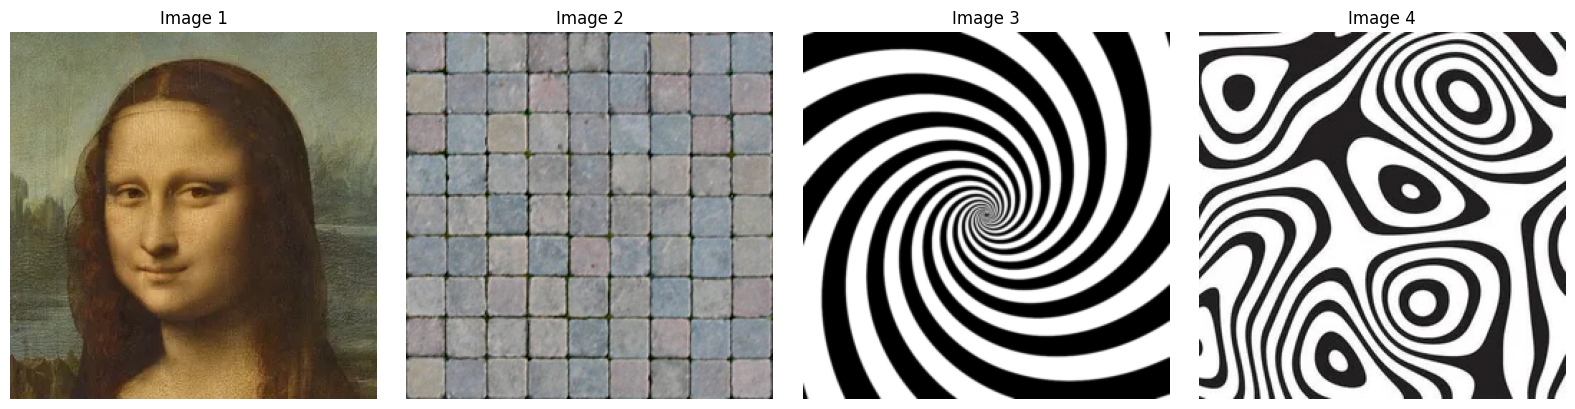

In [59]:
def plot_four_images(img1, img2, img3, img4, figsize=(16, 4), titles=None):
    """
    Plot 4 images horizontally.

    Parameters
    ----------
    img1, img2, img3, img4 : array-like
        Images that can be displayed by plt.imshow().
    figsize : tuple
        Figure size.
    titles : list or tuple of length 4, optional
        Titles for the 4 images.
    """
    images = [img1, img2, img3, img4]

    if titles is None:
        titles = ["Image 1", "Image 2", "Image 3", "Image 4"]

    fig, axes = plt.subplots(1, 4, figsize=figsize)

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    
plot_four_images(unload_image(mn_img), unload_image(tiles_img), unload_image(spiral_img), unload_image(abstract_img))

In [60]:
import math
import matplotlib.pyplot as plt

def plot_snapshots(snapshots, cols=4, figsize=(16, 12), suptitle="Style Transfer Progress"):
    """
    Plot all snapshots in one figure.

    Parameters
    ----------
    snapshots : list of (step, PIL.Image)
        Example: [(100, img1), (200, img2), ...]
    cols : int
        Number of columns in the grid.
    figsize : tuple
        Figure size.
    suptitle : str
        Overall title for the figure.
    """
    if len(snapshots) == 0:
        print("No snapshots to display.")
        return

    n = len(snapshots)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = list(axes)
    else:
        axes = axes.flatten()

    for ax, (step, img) in zip(axes, snapshots):
        ax.imshow(img)
        ax.set_title(f"Iter {step}")
        ax.axis("off")

    # Hide unused axes
    for ax in axes[len(snapshots):]:
        ax.axis("off")

    plt.suptitle(suptitle, fontsize=16)
    plt.tight_layout()
    plt.show()

Iteration 1/300 | Style Loss: 0.0002778 | Normalised Style Loss: 0.2499977 | Content Loss: 3.5019650
Iteration 100/300 | Style Loss: 0.0000128 | Normalised Style Loss: 0.0115323 | Content Loss: 8.7442760
Iteration 200/300 | Style Loss: 0.0000085 | Normalised Style Loss: 0.0076929 | Content Loss: 8.4528446
Iteration 300/300 | Style Loss: 0.0000072 | Normalised Style Loss: 0.0064521 | Content Loss: 8.2921047


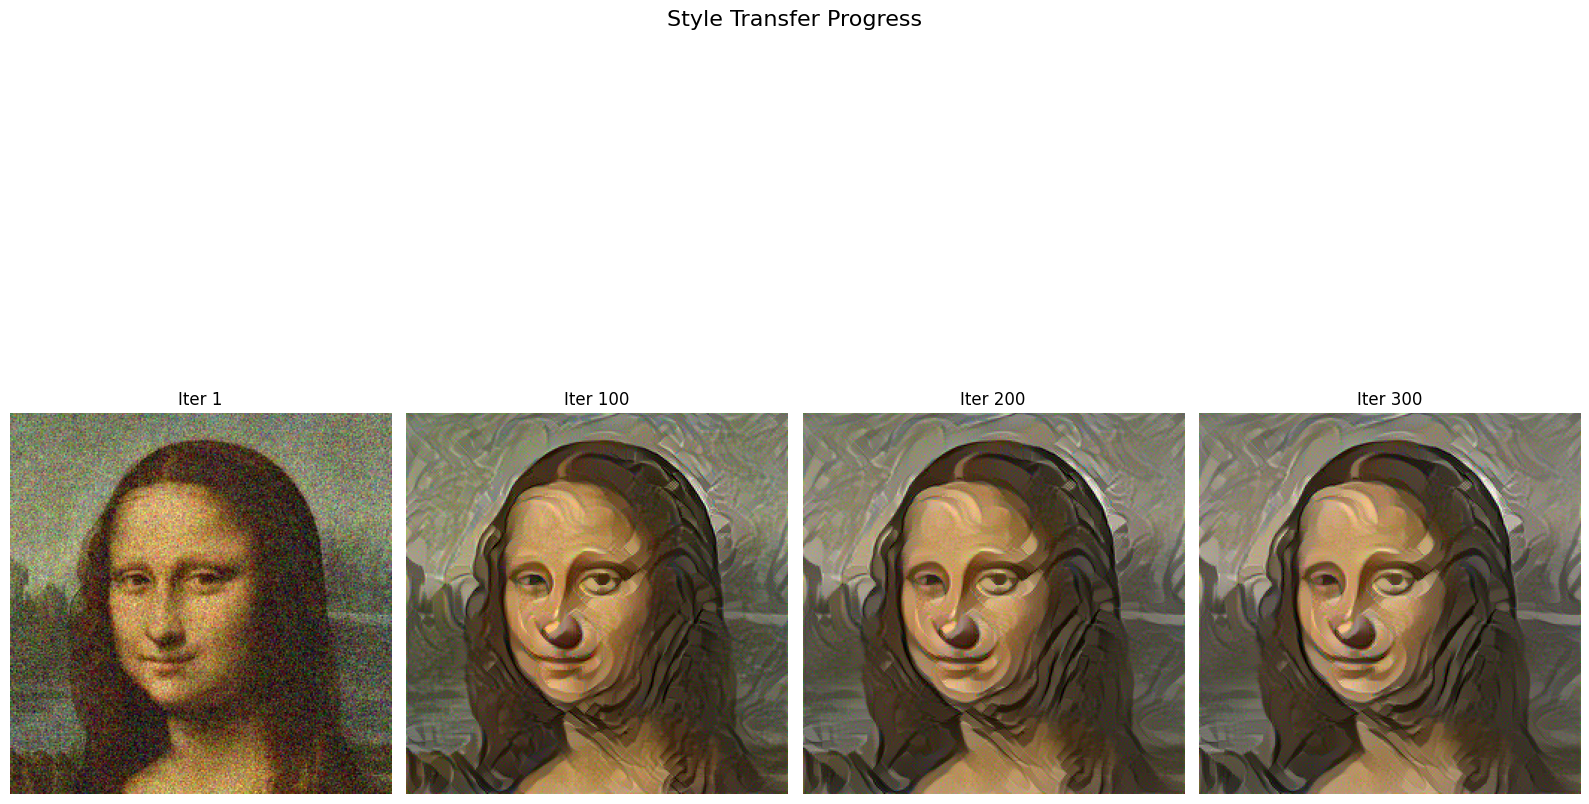

In [62]:

style_img = load_image(abstract_img_path, loader)
content_img = load_image(mn_img_path, loader)

sfe = StyleFeaturesExtractor(
    cnn=cnn,
    style_img=style_img,
    normalization_mean=cnn_normalization_mean,
    normalization_std=cnn_normalization_std,
)

cfe = ContentFeaturesExtractor(
    model=sfe.model,
    content_img=content_img,
)

generated_image, snapshot = run_style_transfer_inter(style_features_extractor=sfe,
                            content_features_extractor=cfe,
                            num_steps=300,
                            style_weight=100,
                            content_weight=0.1,
                            display_intermediate=False
                            )

plot_snapshots(snapshots=snapshot)

